In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Define the folder containing the SQL analytical exports
data_path = r"C:\Users\john-\OneDrive\桌面\eleven\第二版\sql导出csv"
# Load monthly seller performance data for seller and operational analysis
seller_performance = pd.read_csv(
    os.path.join(data_path, "seller_performance.csv"),
    header=None,
    names=[
        "year","quarter","month","month_name","month_number","month_period",
        "seller_id","seller_name","seller_state","revenue","orders",
        "units_sold","aov","month_start_date"
    ]
)
# Load monthly payment performance data for payment method analysis
payment_performance = pd.read_csv(
    os.path.join(data_path, "payment_performance.csv"),
    header=None,
    names=[
        "year","quarter","month","month_name","month_number","month_period",
        "payment_type","orders","payment_value","avg_payment_per_order",
        "avg_installments","month_start_date"
    ]
)
# Load monthly delivery and review data for operational quality analysis
delivery_review = pd.read_csv(
    os.path.join(data_path, "delivery_review.csv"),
    header=None,
    names=[
        "year","quarter","month","month_name","month_number","month_period",
        "review_score","orders","avg_delivery_days","avg_estimated_days",
        "late_orders","late_rate_pct","month_start_date"
    ]
)
# Convert monthly date fields to pandas datetime format
seller_performance["month_start_date"] = pd.to_datetime(
    seller_performance["month_start_date"]
)
payment_performance["month_start_date"] = pd.to_datetime(
    payment_performance["month_start_date"]
)
delivery_review["month_start_date"] = pd.to_datetime(
    delivery_review["month_start_date"]
)
# Verify imported dataset dimensions
print("seller_performance:", seller_performance.shape)
print("payment_performance:", payment_performance.shape)
print("delivery_review:", delivery_review.shape)

seller_performance: (42000, 14)
payment_performance: (588, 12)
delivery_review: (420, 13)


In [2]:
# Check dataset completeness and time coverage before operational analysis
print("Seller NULLs:", seller_performance.isna().sum().sum())
print("Payment NULLs:", payment_performance.isna().sum().sum())
print("Delivery NULLs:", delivery_review.isna().sum().sum())
print("Unique Sellers:", seller_performance["seller_id"].nunique())
print("Payment Types:", payment_performance["payment_type"].nunique())
print("Review Scores:", sorted(delivery_review["review_score"].unique()))
print(
    "Delivery Review Date Range:",
    delivery_review["month_start_date"].min(),
    "to",
    delivery_review["month_start_date"].max()
)

Seller NULLs: 0
Payment NULLs: 0
Delivery NULLs: 0
Unique Sellers: 500
Payment Types: 7
Review Scores: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Delivery Review Date Range: 2019-01-01 00:00:00 to 2025-12-01 00:00:00


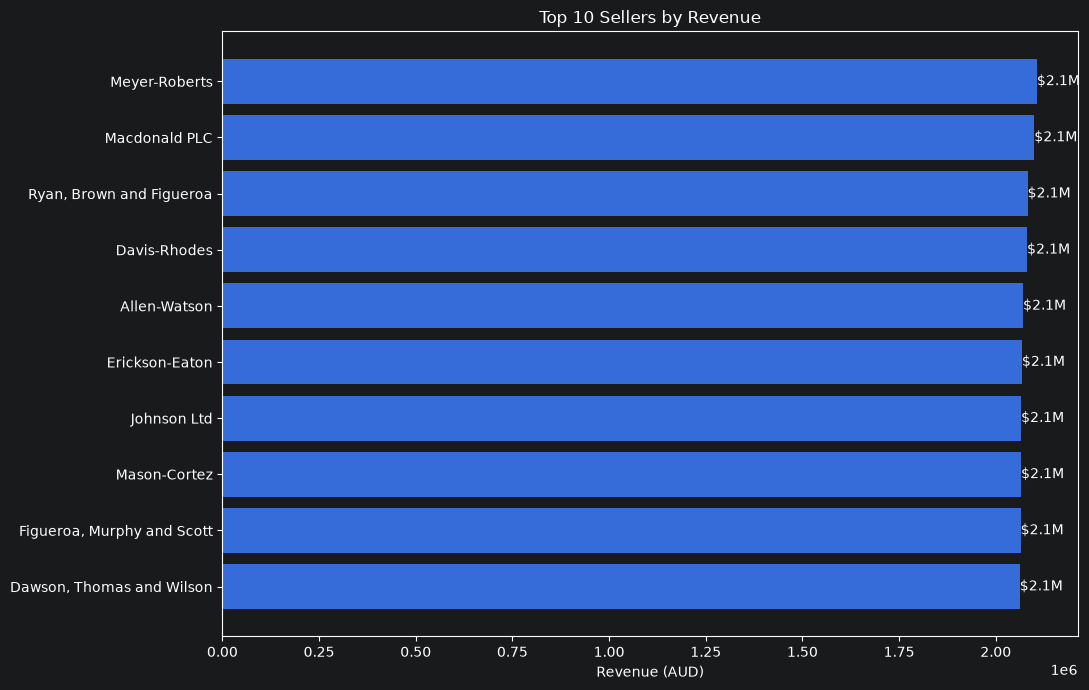

In [4]:
# Aggregate seller performance across the full analysis period
seller_analysis = seller_performance.groupby(
    ["seller_id", "seller_name", "seller_state"],
    as_index=False
).agg(
    revenue=("revenue", "sum"),
    orders=("orders", "sum"),
    units_sold=("units_sold", "sum")
)
# Calculate average order value and revenue share for each seller
seller_analysis["aov"] = (
    seller_analysis["revenue"] /
    seller_analysis["orders"]
)
seller_analysis["revenue_share_pct"] = (
    seller_analysis["revenue"] /
    seller_analysis["revenue"].sum() * 100
)
# Rank sellers by revenue
seller_analysis = seller_analysis.sort_values(
    "revenue",
    ascending=False
).reset_index(drop=True)
seller_analysis["revenue_rank"] = seller_analysis.index + 1
seller_analysis.head(10)

# Select the top 10 sellers by revenue for portfolio visualization
top10_sellers = seller_analysis.head(10).sort_values("revenue")
fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(
    top10_sellers["seller_name"],
    top10_sellers["revenue"]
)
# Add revenue labels to each seller
for bar, value in zip(bars, top10_sellers["revenue"]):
    ax.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"${value / 1_000_000:.1f}M",
        va="center"
    )
ax.set_title("Top 10 Sellers by Revenue")
ax.set_xlabel("Revenue (AUD)")
plt.tight_layout()
plt.show()

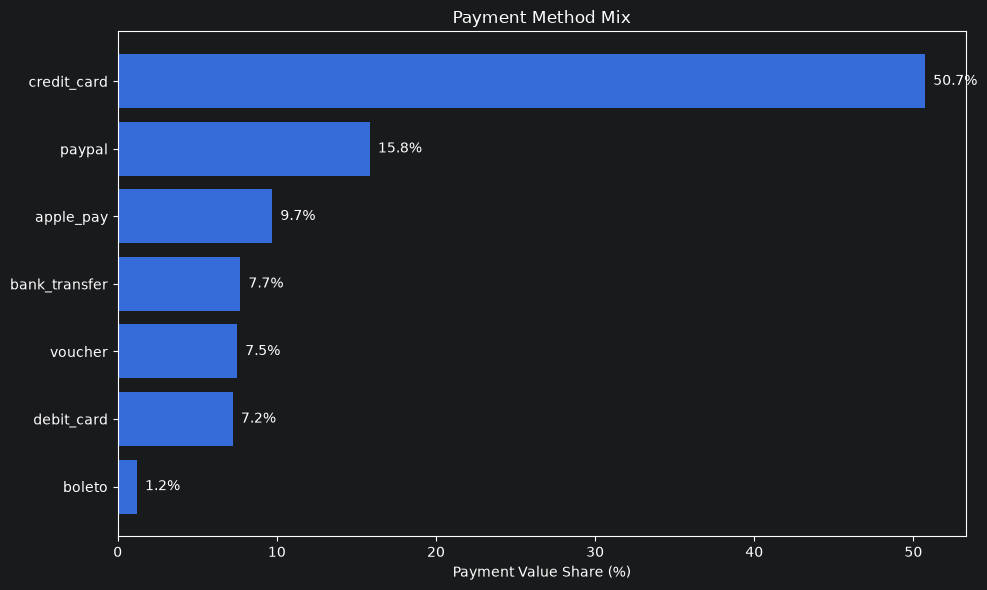

In [6]:
# Aggregate payment performance by payment method
payment_analysis = payment_performance.groupby(
    "payment_type",
    as_index=False
).agg(
    orders=("orders", "sum"),
    payment_value=("payment_value", "sum"),
    avg_installments=("avg_installments", "mean")
)
# Calculate payment value share for each payment method
payment_analysis["payment_share_pct"] = (
    payment_analysis["payment_value"] /
    payment_analysis["payment_value"].sum() * 100
)
payment_analysis = payment_analysis.sort_values(
    "payment_value",
    ascending=False
)
payment_analysis

# Visualize payment value distribution across payment methods
payment_chart = payment_analysis.sort_values("payment_share_pct")
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    payment_chart["payment_type"],
    payment_chart["payment_share_pct"]
)
# Add percentage labels to each payment method
for bar, value in zip(
    bars,
    payment_chart["payment_share_pct"]
):
    ax.text(
        value + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center"
    )
ax.set_title("Payment Method Mix")
ax.set_xlabel("Payment Value Share (%)")
plt.tight_layout()
plt.show()

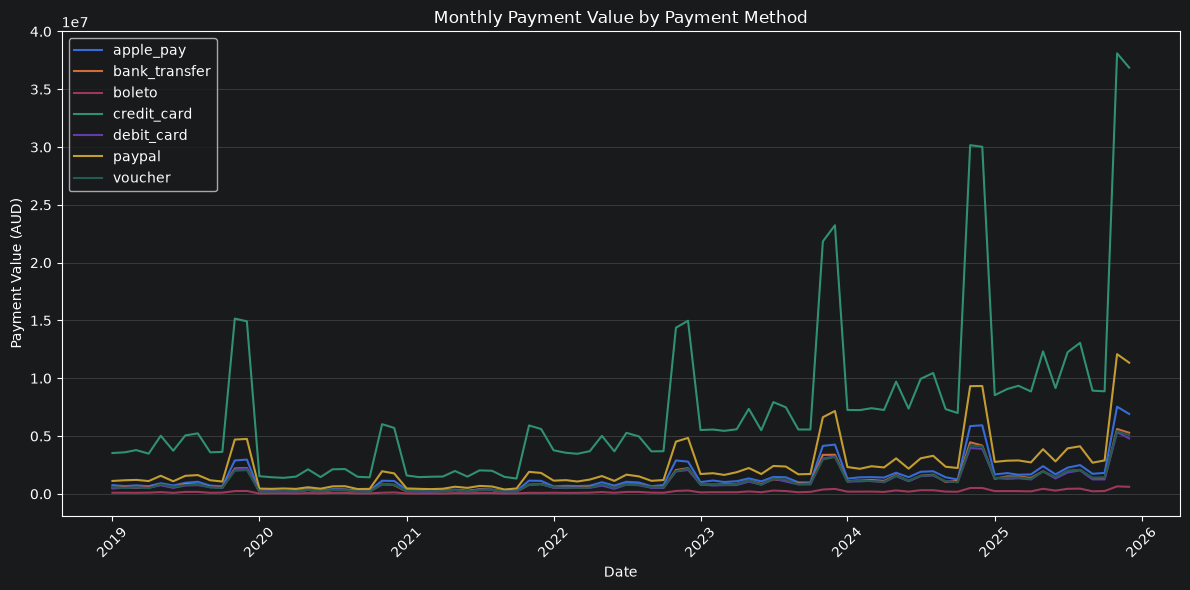

In [7]:
# Aggregate monthly payment value by payment method
payment_trend = payment_performance.groupby(
    ["month_start_date", "payment_type"],
    as_index=False
).agg(
    payment_value=("payment_value", "sum")
)
# Create a multi-line trend showing payment method usage over time
fig, ax = plt.subplots(figsize=(12, 6))
for payment_type, group in payment_trend.groupby("payment_type"):
    ax.plot(
        group["month_start_date"],
        group["payment_value"],
        label=payment_type
    )
ax.set_title("Monthly Payment Value by Payment Method")
ax.set_xlabel("Date")
ax.set_ylabel("Payment Value (AUD)")
ax.tick_params(axis="x", rotation=45)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

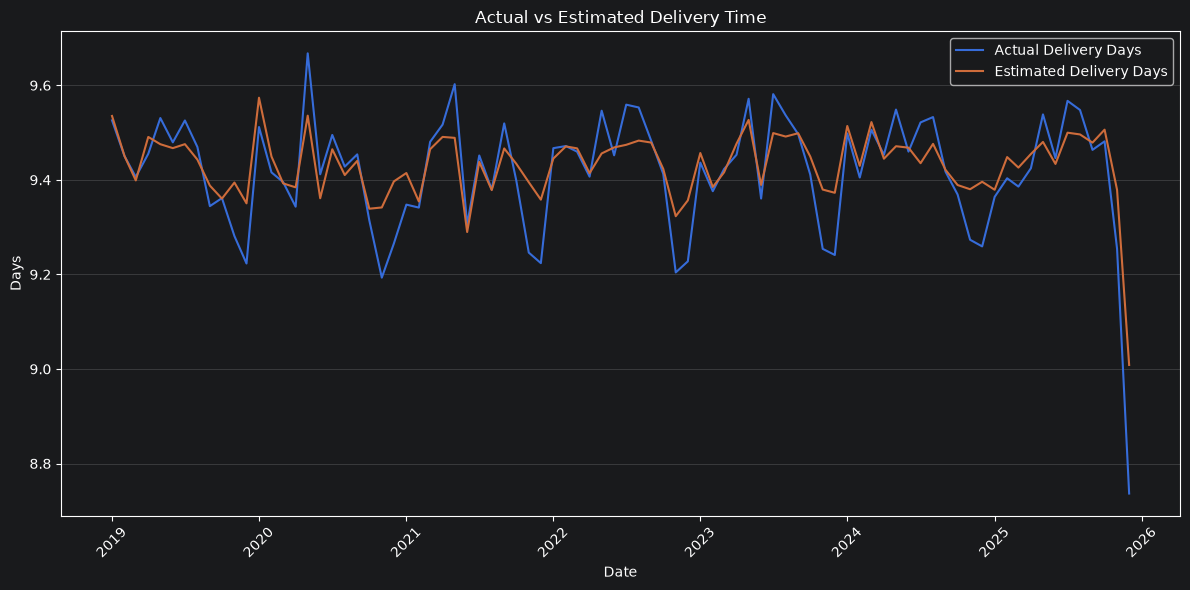

In [9]:
# Aggregate delivery performance across all review records
delivery_analysis = delivery_review.groupby(
    "month_start_date",
    as_index=False
).agg(
    orders=("orders", "sum"),
    avg_delivery_days=("avg_delivery_days", "mean"),
    avg_estimated_days=("avg_estimated_days", "mean"),
    late_orders=("late_orders", "sum")
)
# Calculate the monthly late delivery rate
delivery_analysis["late_rate_pct"] = (
    delivery_analysis["late_orders"] /
    delivery_analysis["orders"] * 100
)
delivery_analysis.head()

# Compare actual delivery time with estimated delivery time over time
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    delivery_analysis["month_start_date"],
    delivery_analysis["avg_delivery_days"],
    label="Actual Delivery Days"
)
ax.plot(
    delivery_analysis["month_start_date"],
    delivery_analysis["avg_estimated_days"],
    label="Estimated Delivery Days"
)
ax.set_title("Actual vs Estimated Delivery Time")
ax.set_xlabel("Date")
ax.set_ylabel("Days")
ax.tick_params(axis="x", rotation=45)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

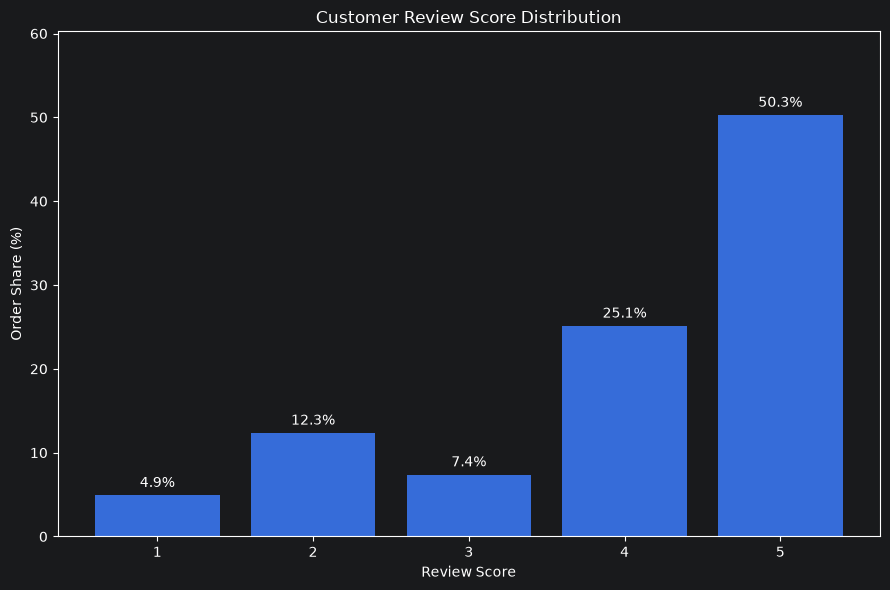

In [11]:
# Aggregate review performance by review score
review_analysis = delivery_review.groupby(
    "review_score",
    as_index=False
).agg(
    orders=("orders", "sum"),
    avg_delivery_days=("avg_delivery_days", "mean"),
    avg_estimated_days=("avg_estimated_days", "mean"),
    late_orders=("late_orders", "sum")
)
# Calculate the share of orders represented by each review score
review_analysis["review_share_pct"] = (
    review_analysis["orders"] /
    review_analysis["orders"].sum() * 100
)
review_analysis

# Visualize the distribution of customer review scores
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(
    review_analysis["review_score"].astype(str),
    review_analysis["review_share_pct"]
)
# Add percentage labels above each review score
for bar, value in zip(
    bars,
    review_analysis["review_share_pct"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )
ax.set_title("Customer Review Score Distribution")
ax.set_xlabel("Review Score")
ax.set_ylabel("Order Share (%)")
ax.set_ylim(0, max(review_analysis["review_share_pct"]) + 10)
plt.tight_layout()
plt.show()

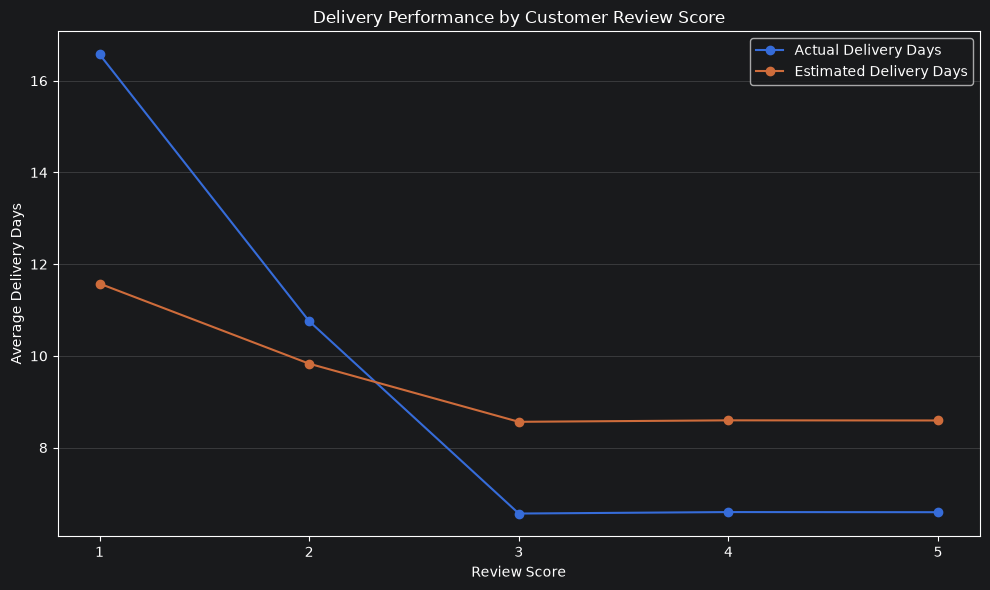

In [12]:
# Compare delivery performance across different customer review scores
fig, ax = plt.subplots(figsize=(10, 6))
x = review_analysis["review_score"]
ax.plot(
    x,
    review_analysis["avg_delivery_days"],
    marker="o",
    label="Actual Delivery Days"
)
ax.plot(
    x,
    review_analysis["avg_estimated_days"],
    marker="o",
    label="Estimated Delivery Days"
)
ax.set_title("Delivery Performance by Customer Review Score")
ax.set_xlabel("Review Score")
ax.set_ylabel("Average Delivery Days")
ax.set_xticks(x)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# Calculate key operational KPIs for the final business analysis
operations_kpi = pd.DataFrame({
    "Metric": [
        "Total Sellers",
        "Total Payment Value",
        "Average Delivery Days",
        "Average Estimated Delivery Days",
        "Late Delivery Rate",
        "Average Review Score"
    ],
    "Value": [
        seller_analysis["seller_id"].nunique(),
        payment_analysis["payment_value"].sum(),
        delivery_analysis["avg_delivery_days"].mean(),
        delivery_analysis["avg_estimated_days"].mean(),
        delivery_analysis["late_orders"].sum() /
        delivery_analysis["orders"].sum() * 100,
        np.average(
            review_analysis["review_score"],
            weights=review_analysis["orders"]
        )
    ]
})
operations_kpi

,Metric,Value
0,Total Sellers,5.000000e+02
1,Total Payment Value,1.222185e+09
2,Average Delivery Days,9.416699e+00
3,Average Estimated Delivery Days,9.431315e+00
4,Late Delivery Rate,9.857478e+00
5,Average Review Score,4.034775e+00


Key Operations Insights
Seller Performance

The dataset contains 500 sellers, and the top 10 sellers each contribute approximately 0.21% of total revenue. No individual seller accounts for a large proportion of total sales, indicating that revenue is broadly distributed across the seller base.

Payment Method

Credit card is the dominant payment method, accounting for 50.75% of total payment value. PayPal is the second-largest payment method at 15.85%, followed by Apple Pay at 9.72%.

Delivery Performance

Average actual delivery time is 9.42 days, compared with an average estimated delivery time of 9.43 days. The overall late delivery rate is 9.86%, indicating that actual delivery performance is broadly aligned with the estimated delivery schedule.

Customer Review Performance

The average customer review score is 4.03 out of 5. Half of all reviewed orders receive a 5-star rating, while 25.11% receive a 4-star rating.

Delivery and Customer Satisfaction

Lower review scores are associated with longer delivery times and higher late-delivery rates. Orders receiving a 1-star review have an average delivery time of 16.58 days and a 100% late-delivery rate, compared with approximately 6.59 days for 4- and 5-star reviews. This analysis identifies an association between delivery performance and customer satisfaction but does not establish a causal relationship.

Overall Operations Insight

Operational performance is generally stable, with diversified seller participation, a clear preference for credit card payments, delivery times broadly aligned with estimated schedules, and an average review score above 4.0. Delivery performance appears to be an important operational factor associated with customer satisfaction.